## Classifier: Random Forests

In [34]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parents[1]))
from src.utils import conf_matrix, plot_roc_curve

In [35]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

import pandas as pd

# import data and libs
data = pd.read_csv('../../data/processed/creditcard-processed.csv')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Model Creation

In [36]:
X = data.drop('Class', axis=1)
y = data['Class']

scaler = StandardScaler()

xtrain, xtest, ytrain, ytest = train_test_split(
    X, y, random_state=42, stratify=y
)
xtrain_scld = scaler.fit_transform(xtrain)
xtest_scld = scaler.transform(xtest)

_rf = RandomForestClassifier()
_rf.fit(xtrain_scld, ytrain)
_rf_pred = _rf.predict(xtest_scld)
_rf_prob = _rf.predict_proba(xtest_scld)[:,1]
threshold = (_rf_prob >= 0.80).astype(int)

test_score = _rf.score(xtest_scld, ytest)
accuracy = _rf.score(xtrain_scld, ytrain)
print(f"Test Score: {test_score:.3f}")
print(f"Accuracy Score: {accuracy:.3f}")

Test Score: 1.000
Accuracy Score: 1.000


## ROC Curve

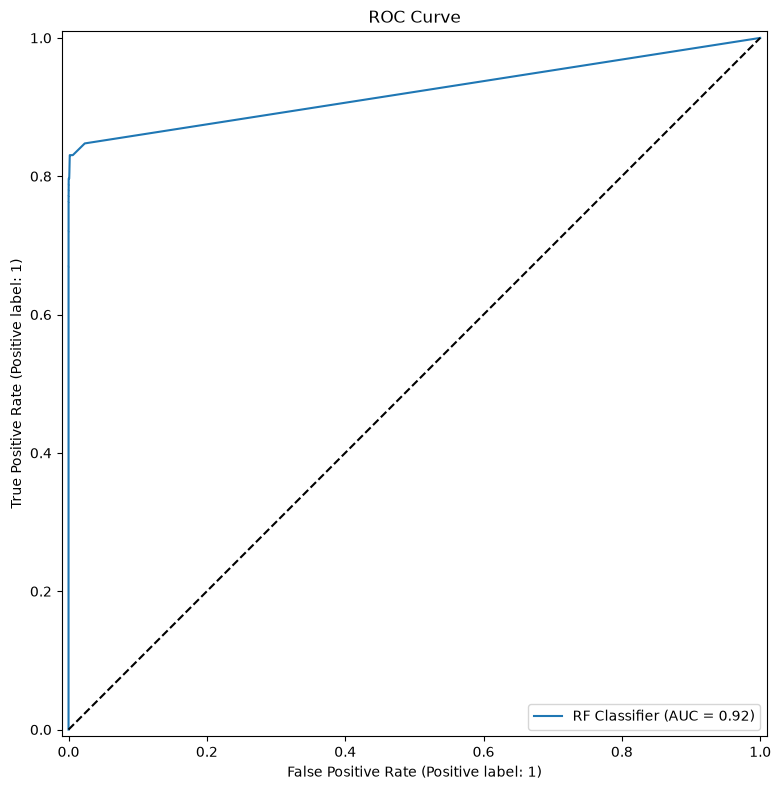

In [44]:
plot_roc_curve(_rf, xtest_scld, ytest, 'RF Classifier')

## Confusion Matrices (with and without 80% threshold)

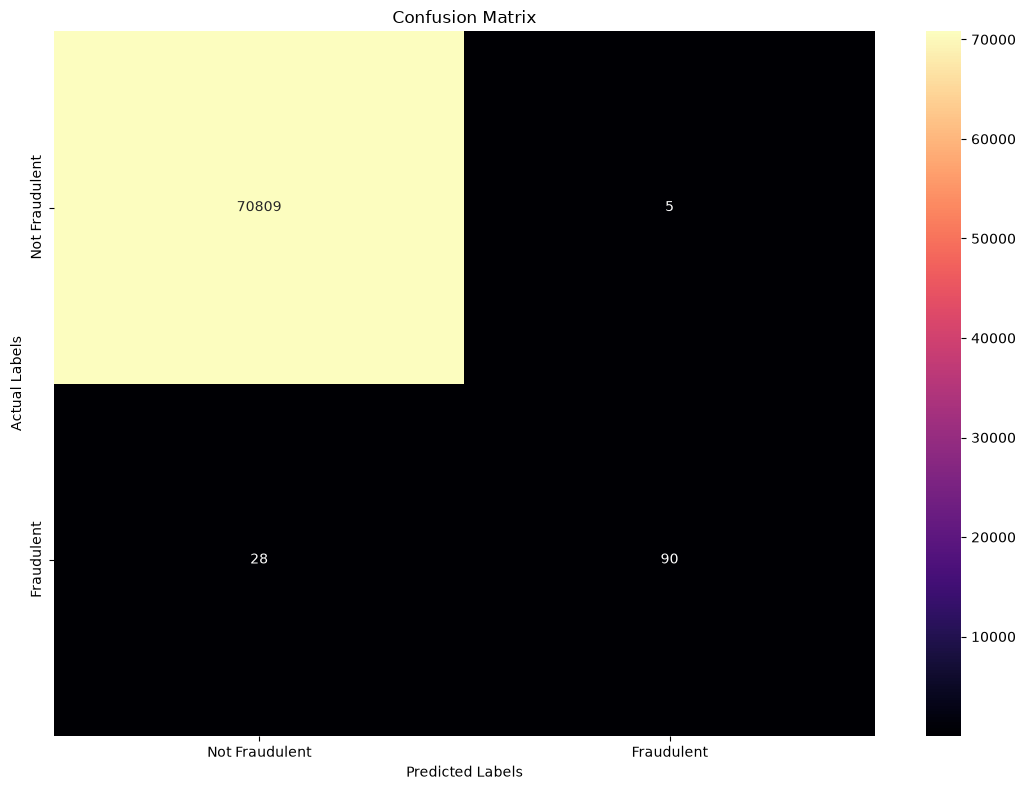

In [38]:
conf_matrix(ytest, _rf_pred, ['Not Fraudulent', 'Fraudulent'])

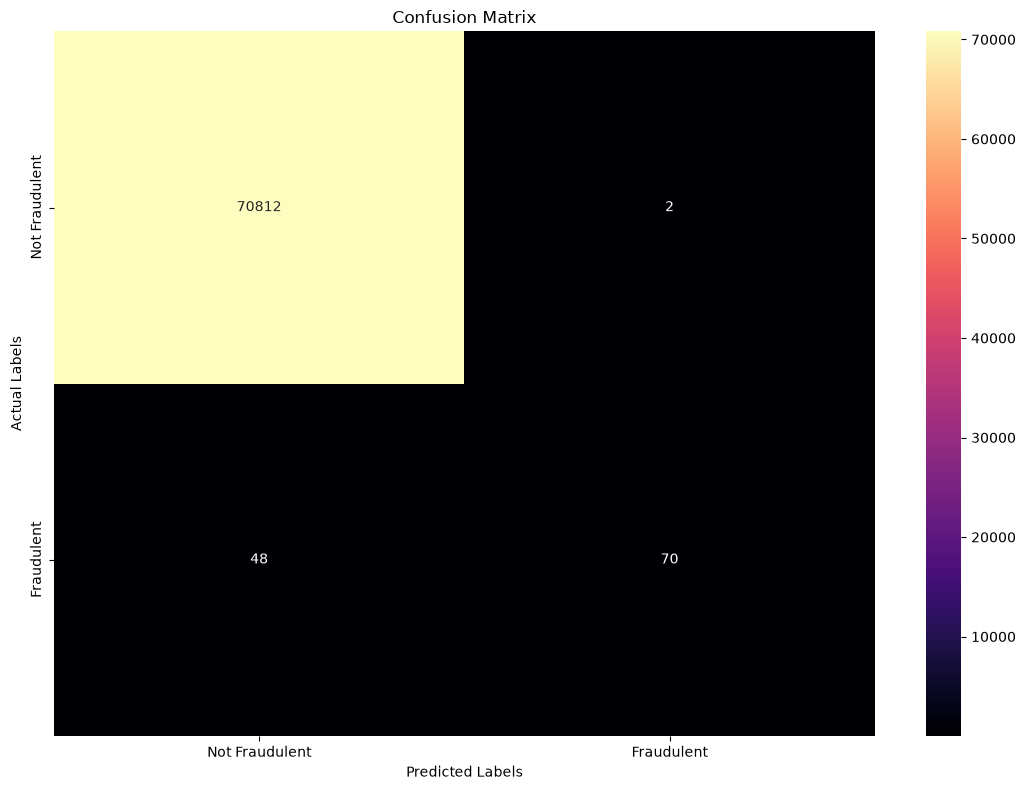

In [39]:
conf_matrix(ytest, threshold, ['Not Fraudulent', 'Fraudulent'])

## Classification Report (with and without 80% threshold)

In [40]:
print(classification_report(ytest, _rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.95      0.76      0.85       118

    accuracy                           1.00     70932
   macro avg       0.97      0.88      0.92     70932
weighted avg       1.00      1.00      1.00     70932



In [41]:
print(classification_report(ytest, threshold))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.97      0.59      0.74       118

    accuracy                           1.00     70932
   macro avg       0.99      0.80      0.87     70932
weighted avg       1.00      1.00      1.00     70932



## Dataset Sampling using SMOTE sampling

In [42]:
smote = SMOTE(random_state=42)

xtrain_smote, ytrain_smote = smote.fit_resample(xtrain, ytrain)
xtrain_smote_scaled = scaler.transform(xtrain_smote)

rf = RandomForestClassifier()
rf.fit(xtrain_smote_scaled, ytrain_smote)
rf_smote = rf.predict(xtest_scld)

test_score = rf.score(xtest_scld, ytest)
accuracy = rf.score(xtrain_smote_scaled, ytrain_smote)
print(f"Test Score: {test_score:.3f}")
print(f"Accuracy Score: {accuracy:.3f}")
print(classification_report(ytest, rf_smote))

Test Score: 0.999
Accuracy Score: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.86      0.79      0.82       118

    accuracy                           1.00     70932
   macro avg       0.93      0.89      0.91     70932
weighted avg       1.00      1.00      1.00     70932



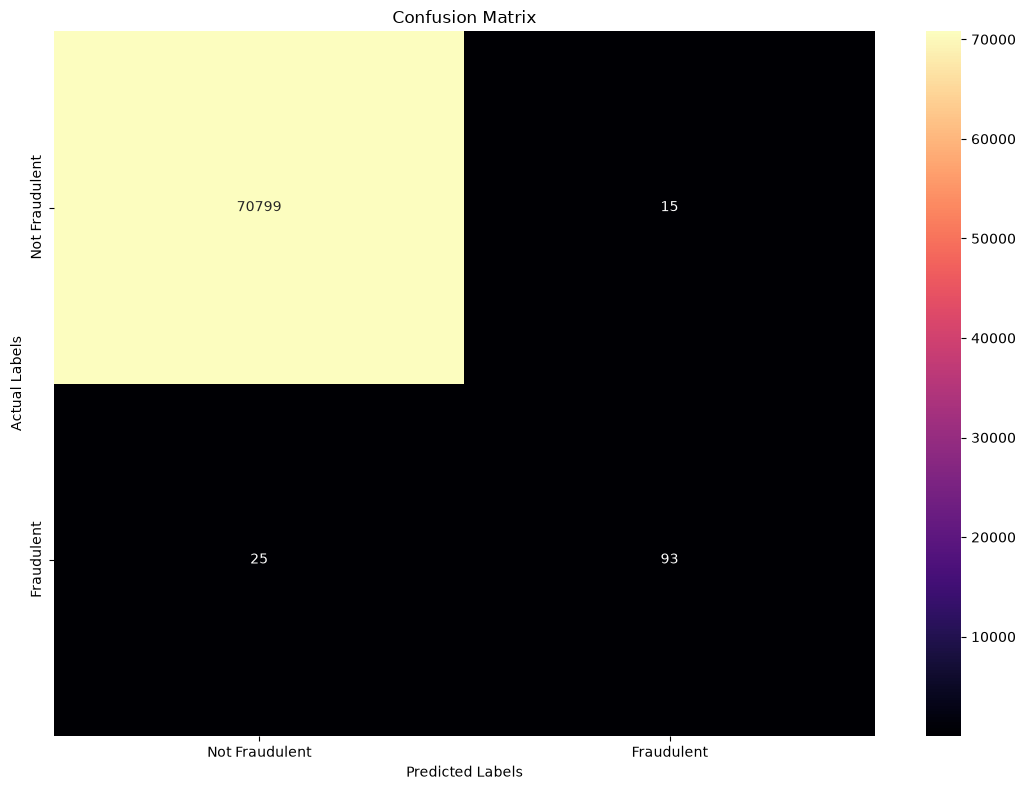

In [43]:
conf_matrix(ytest, rf_smote, ['Not Fraudulent', 'Fraudulent'])